In [1]:
import torch
import torch.nn as nn

device = "cuda"

torch.manual_seed(42)
codings_dim=32

In [2]:
from pathlib import Path
from torchvision import datasets, transforms

DATA_DIR = Path("datasets")

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)

print(len(train_dataset), len(test_dataset))

60000 10000


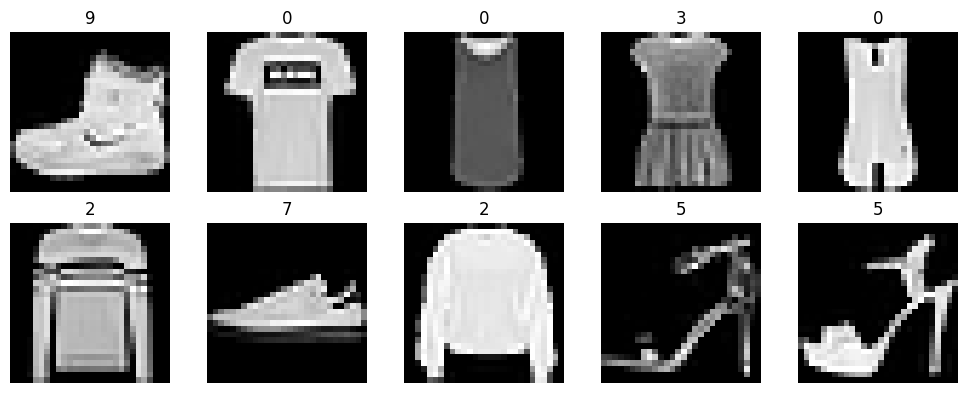

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
from torch.utils.data import DataLoader

codings_dim = 32
generator = nn.Sequential(
    nn.Linear(codings_dim, 128), nn.ReLU(),
    nn.Linear(128, 256), nn.ReLU(),
    nn.Linear(256, 1*28*28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1,28,28))
).to(device)

discriminator = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1*28*28, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 1), nn.Sigmoid()
).to(device)

def train_gen(generator:nn.Module, discriminator:nn.Module, train_loader:DataLoader, 
              codings_dim:int, n_epochs:int=20, g_lr:float=1e-3, d_lr:float=5e-4):
    criterion = nn.BCELoss()
    generator_opt = torch.optim.NAdam(generator.parameters(), lr=g_lr)
    discriminator_opt = torch.optim.NAdam(discriminator.parameters(), lr=d_lr)
    for epoch in range(n_epochs):
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            pred_real = discriminator(real_images)
            batch_size = real_images.size(0)
            ones = torch.ones(batch_size, 1, device=device)
            real_loss = criterion(pred_real, ones)

            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings).detach()
            pred_fake = discriminator(fake_images)
            zeros = torch.zeros(batch_size, 1, device=device)
            fake_loss = criterion(pred_fake, zeros)

            discriminator_loss = real_loss + fake_loss
            discriminator_opt.zero_grad()
            discriminator_loss.backward()
            discriminator_opt.step()
            
            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings)
            for p in discriminator.parameters():
                p.requires_grad = False
            pred_fake = discriminator(fake_images)
            generator_loss = criterion(pred_fake, ones)
            generator_opt.zero_grad()
            generator_loss.backward()
            generator_opt.step()
            for p in discriminator.parameters():
                p.requires_grad = True



In [15]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32, pin_memory=True)

train_gen(generator, discriminator, train_loader, codings_dim, 1)

In [ ]:
generator.eval()
n_images = 10
codings = torch.randn(n_images, codings_dim, device=device)
with torch.no_grad():
    generated_images = generator(codings)

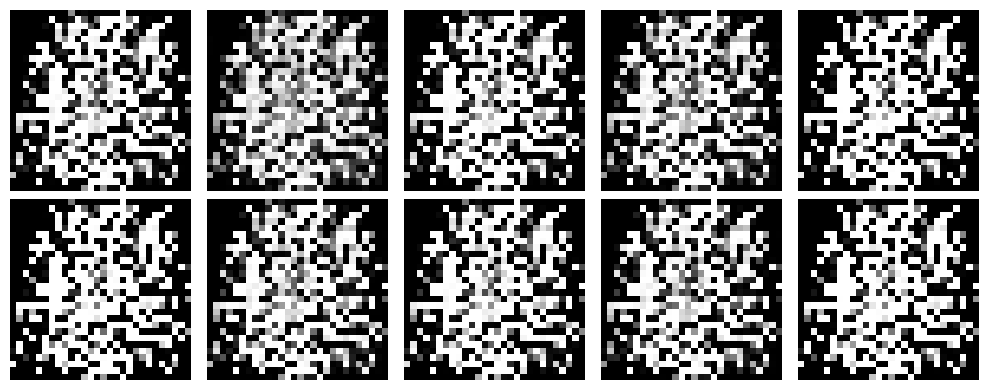

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img in zip(axes.flat, generated_images):
    ax.imshow(img.squeeze().cpu(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()